In [2]:
import pandas as pd

df = pd.read_csv("Housing.csv")

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
df.shape

(545, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)

In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df = pd.get_dummies(df, drop_first=True)

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [13]:
numeric_cols

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [14]:
categorical_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [19]:
X = df.drop("price", axis=1)
y = df["price"]

In [20]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,y,
test_size=0.2,
random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
lr_pred = lr.predict(X_test)

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
n_estimators=100,
random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [26]:
mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
r2 = r2_score(y_test, lr_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 970043.4039201637
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


In [27]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 1021546.0353211008
Random Forest RMSE: 1400565.9728553821
Random Forest R2: 0.611918531405699


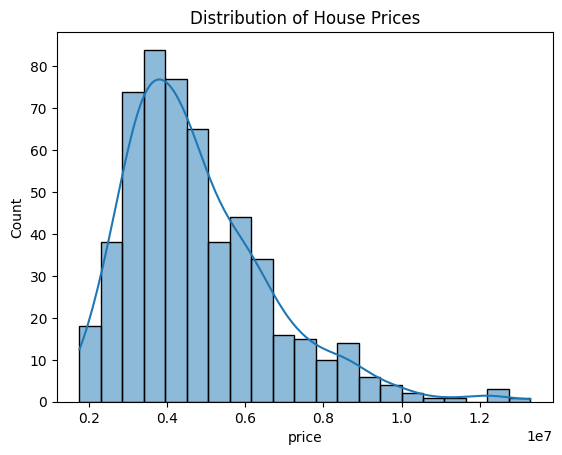

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

In [34]:
import os

os.makedirs("charts", exist_ok=True)

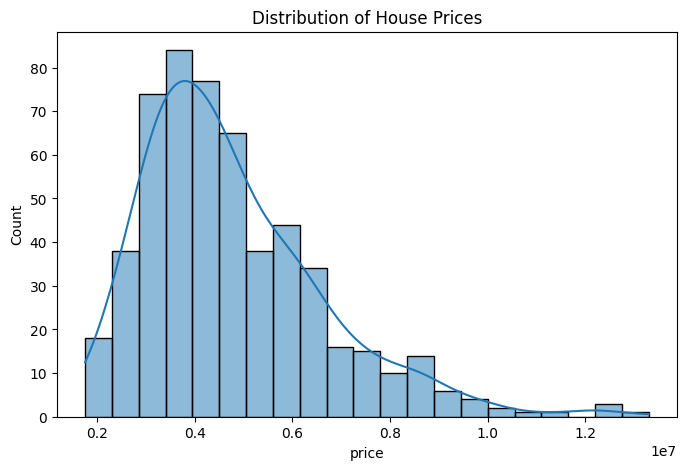

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")

plt.savefig("charts/price_distribution.png")
plt.show()

<Axes: >

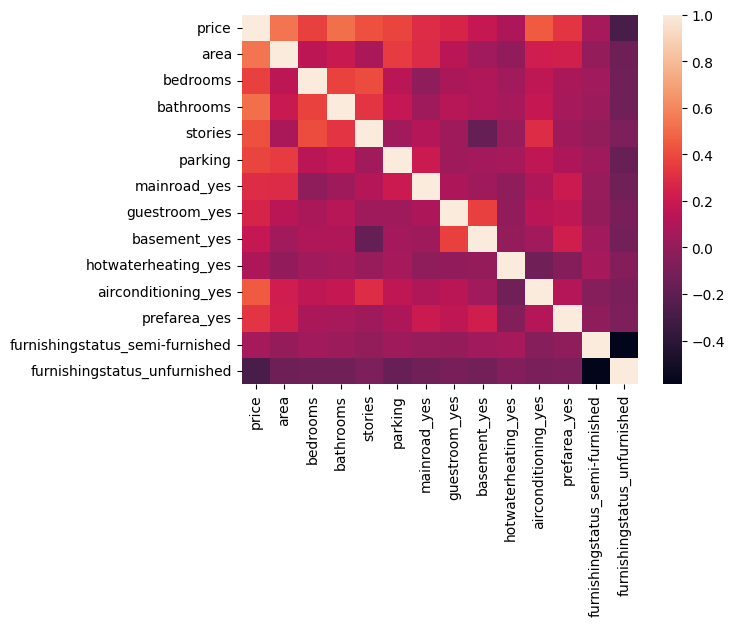

In [36]:
sns.heatmap(df.corr())

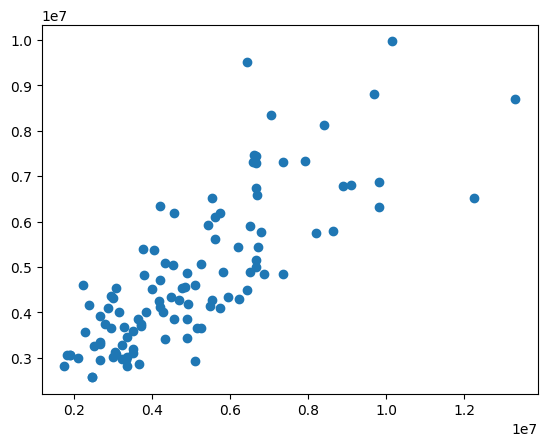

In [37]:
plt.scatter(y_test, rf_pred)

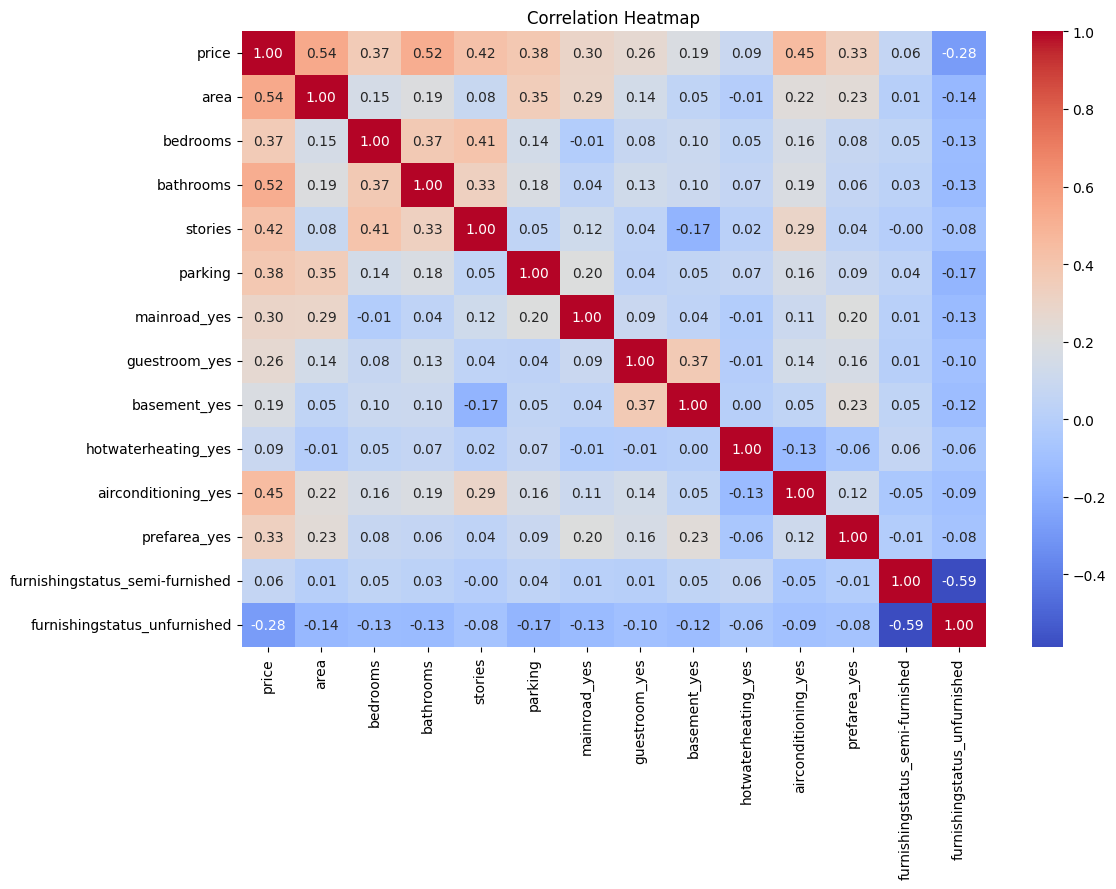

In [38]:
import os
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

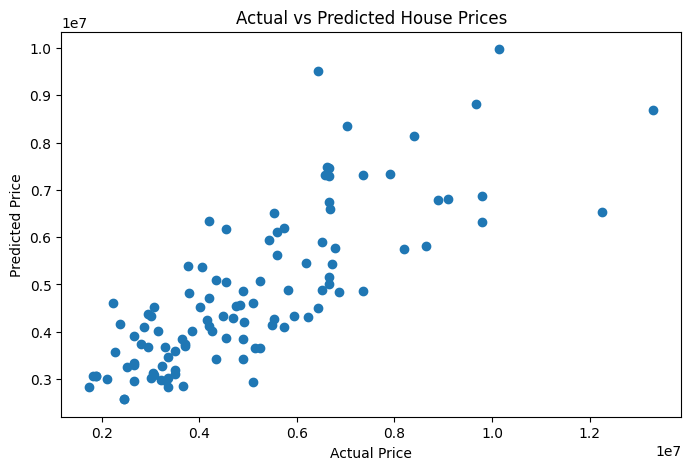

In [39]:
import os
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig(
    "charts/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

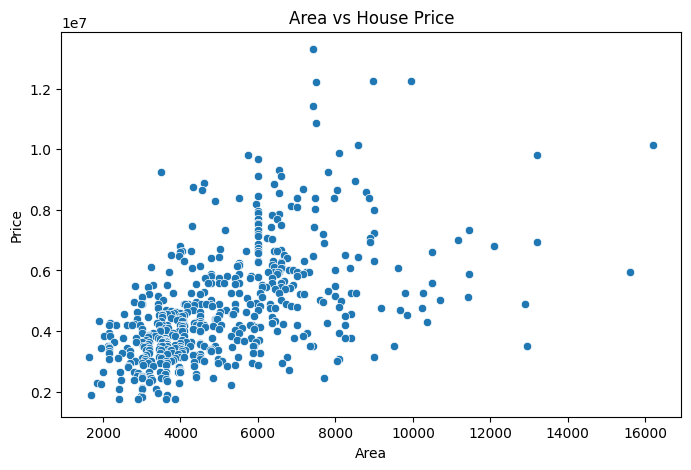

In [42]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["area"],
    y=df["price"]
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.savefig(
    "charts/area_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
import os

print(os.listdir("charts"))

['actual_vs_predicted.png', 'area_vs_price.png', 'correlation_heatmap.png', 'price_distribution.png']


In [44]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


In [45]:
print("Linear Regression R2 Score:", r2)
print("Random Forest R2 Score:", rf_r2)
print("Random Forest MAE:", rf_mae)

Linear Regression R2 Score: 0.6529242642153184
Random Forest R2 Score: 0.611918531405699
Random Forest MAE: 1021546.0353211008


In [ ]:
1. Which features influence house price the most?

Area of the house
Number of bathrooms
Parking availability
Number of stories
Air conditioning
Preferred area (location)

In [ ]:
2. How accurate was your model (in plain terms)?

The Random Forest model performed better than Linear Regression.
The model predicted house prices reasonably well.
Most predicted prices were close to the actual house prices.
The model can be used as a reliable tool for estimating property values.

In [ ]:
3. What surprised you in the data?

Location (preferred area) had a strong impact on house prices.
Air conditioning significantly increased property value.
Some houses with similar sizes had different prices due to amenities and location.
Features other than area also played an important role in determining price.

In [ ]:
4. One recommendation for a real estate business based on your findings

Focus on properties in preferred locations.
Highlight amenities such as air conditioning and parking in advertisements.
Invest in larger properties with more bathrooms and stories.
Use data-driven pricing strategies to estimate fair market value and attract buyers.